# Imports Libraries

In [10]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import os
import pickle

# Load Dataset

In [11]:
df = pd.read_csv(
    r"C:\Users\hp\Documents\ClimateGuardAI\datasets\engineered\heatwave_risk_engineered.csv"
)

features = [
    'temperature_celsius',
    'humidity',
    'pressure_mb',
    'cloud',
    'wind_kph',
    'visibility_km',
    'air_quality_PM2.5',
    'air_quality_PM10'
]

X = df[features]
y = df['rainfall_risk']

# Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model

In [13]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

# SHAP Explainer

In [14]:
explainer = shap.TreeExplainer(model)

# Save Explainer

In [17]:
model_dir = r"C:\Users\hp\Documents\ClimateGuardAI\backend\ml\artifacts"
os.makedirs(model_dir, exist_ok=True)

with open(
    os.path.join(model_dir, "explainer.pkl"),
    "wb"
) as f:
    pickle.dump(explainer, f)

print("explainer.pkl saved successfully.")

explainer.pkl saved successfully.


# Use only 1000 samples for SHAP

In [18]:
X_test_small = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=42
)

shap_values = explainer.shap_values(X_test_small)

# Explain One Sample

In [25]:
sample = X_test.iloc[[0]]
prediction = model.predict(sample)

print("Prediction:", prediction[0])

single_shap = explainer.shap_values(sample)

# Get the index of the predicted class for 'sample'
predicted_class_idx = list(model.classes_).index(prediction[0])

Prediction: Low


# Waterfall Plot

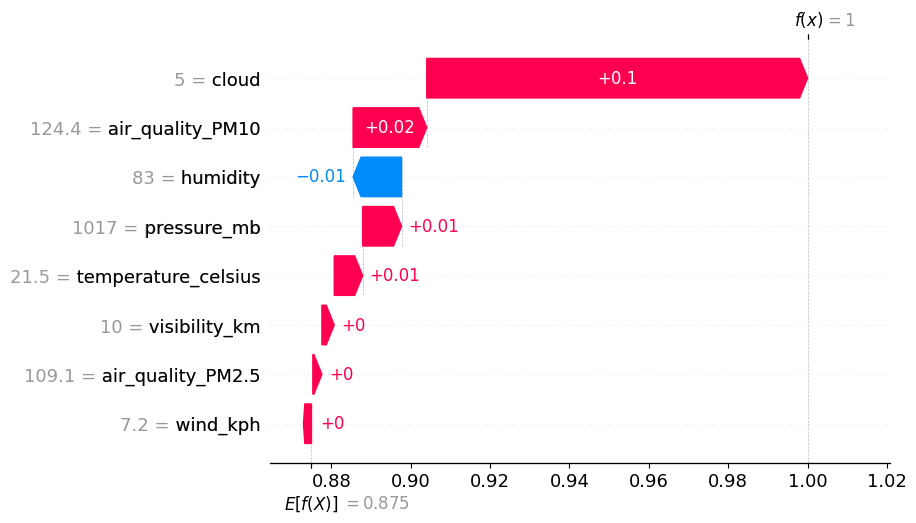

In [26]:
try:
    shap.plots.waterfall(
        shap.Explanation(
            values=single_shap[0, :, predicted_class_idx], # Corrected indexing for single sample and predicted class
            base_values=explainer.expected_value[predicted_class_idx], # Corrected indexing
            data=sample.iloc[0],
            feature_names=sample.columns
        )
    )
except Exception as e:
    print(f"Error generating waterfall plot: {e}")
    print("Waterfall plot not supported with this SHAP version or data structure.")

# Create Explanation Table

In [27]:
# Corrected to ensure contributions is a 1D array for the predicted class
contributions = single_shap[0, :, predicted_class_idx]

sample_shap = pd.DataFrame({
    'Feature': sample.columns,
    'Contribution': contributions
})

sample_shap = sample_shap.sort_values(
    by='Contribution',
    ascending=False
)

sample_shap['Direction'] = np.where(
    sample_shap['Contribution'] > 0,
    'Increase Risk',
    np.where(
        sample_shap['Contribution'] < 0,
        'Decrease Risk',
        'No Impact'
    )
)

sample_shap['Prediction'] = prediction[0]

print(sample_shap)


               Feature  Contribution      Direction Prediction
3                cloud      0.095946  Increase Risk        Low
7     air_quality_PM10      0.018551  Increase Risk        Low
2          pressure_mb      0.009787  Increase Risk        Low
0  temperature_celsius      0.007157  Increase Risk        Low
5        visibility_km      0.003107  Increase Risk        Low
6    air_quality_PM2.5      0.002285  Increase Risk        Low
4             wind_kph      0.000342  Increase Risk        Low
1             humidity     -0.012195  Decrease Risk        Low


# Save CSV

In [29]:
output_file = r"C:\Users\hp\Documents\ClimateGuardAI\datasets\engineered"

output_file = r"C:\Users\hp\Documents\ClimateGuardAI\datasets\engineered\explainable_ai_output.csv"
os.makedirs(os.path.dirname(output_file), exist_ok=True)

sample_shap.to_csv(
    output_file,
    index=False
)

print("explainable_ai_output.csv saved successfully.")

print("explainable_ai_output.csv saved successfully.")

explainable_ai_output.csv saved successfully.
explainable_ai_output.csv saved successfully.


# Print Reasons

In [30]:
print("\nPrediction:", prediction[0])
print("\nReasons:")

for _, row in sample_shap.iterrows():
    if row['Contribution'] > 0:
        print(f"{row['Feature']} ↑")
    elif row['Contribution'] < 0:
        print(f"{row['Feature']} ↓")


Prediction: Low

Reasons:
cloud ↑
air_quality_PM10 ↑
pressure_mb ↑
temperature_celsius ↑
visibility_km ↑
air_quality_PM2.5 ↑
wind_kph ↑
humidity ↓


# Summary Plots

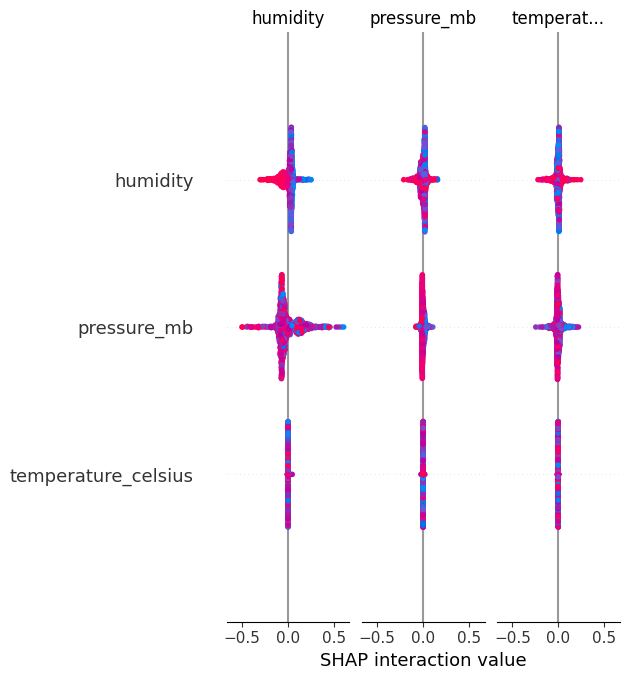

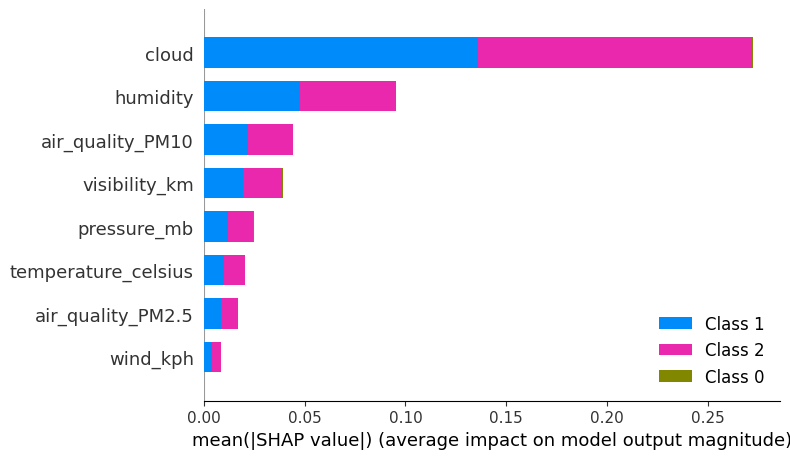

In [31]:
try:
    shap.summary_plot(
        shap_values,
        X_test_small
    )

    shap.summary_plot(
        shap_values,
        X_test_small,
        plot_type='bar'
    )
except Exception as e:
    print(f"Error generating summary plots: {e}")
    print("Summary plots could not be generated.")

# Predict on New Data

In [32]:
new_data = pd.DataFrame({
    'temperature_celsius': [31],
    'humidity': [92],
    'pressure_mb': [998],
    'cloud': [95],
    'wind_kph': [12],
    'visibility_km': [4],
    'air_quality_PM2.5': [45],
    'air_quality_PM10': [70]
})

pred = model.predict(new_data)

print("Predicted Rainfall Risk:", pred[0])

Predicted Rainfall Risk: Medium


# Force Plot

In [33]:
try:
    new_shap = explainer.shap_values(new_data)
    # Get the index of the predicted class for 'new_data'
    new_predicted_class_idx = list(model.classes_).index(pred[0])

    shap.force_plot(
        explainer.expected_value[new_predicted_class_idx], # Corrected indexing
        new_shap[new_predicted_class_idx], # Corrected indexing
        new_data
    )
except Exception as e:
    print(f"Error generating force plot: {e}")
    print("Force plot could not be generated.")

Error generating force plot: index 2 is out of bounds for axis 0 with size 1
Force plot could not be generated.
